# Fase de Calibración de Hiperparámetros (Parameter Tuning)

## 1. Introducción y Justificación Metodológica
En el campo de la Computación Evolutiva, el rendimiento de un algoritmo está intrínsecamente ligado a la configuración de sus parámetros de control. Según Eiben & Smith (2015), comparar una heurística determinista (como *AMD*) contra un Algoritmo Evolutivo (EA) utilizando parámetros arbitrarios carece de rigor científico.

Este notebook tiene como objetivo ejecutar un **ajuste de parámetros (tuning)** para identificar la configuración que maximiza la robustez del algoritmo. El objetivo no es sobre-optimizar para una instancia específica, sino encontrar una configuración general capaz de explorar y explotar eficientemente el espacio de búsqueda del problema *Minimum Fill-in*.

In [1]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Añadimos la raíz del proyecto para importar módulos
sys.path.append('..')

from utils.graph_loader import load_pace_graph
from utils.heuristics import greedy_minimum_degree
from src.tunning import GridSearchTuner

# Configuración visual
sns.set_theme(style="whitegrid")
print("Entorno configurado.")

Entorno configurado.


## 2. Prevención del Sobreajuste (Instancia de Sacrificio)
Para garantizar la validez de los resultados finales, se aplica el protocolo de "Instancia de Sacrificio". Se selecciona un grafo que:
1.  **No pertenece** al conjunto de prueba final (`selected_instances.csv`), evitando así el sesgo de datos (*Data Leakage*).
2.  Posee complejidad estructural moderada ($Fill\text{-}in_{AMD} > 0$).
3.  Tiene un tamaño manejable (40-150 nodos) para permitir múltiples ejecuciones en tiempo razonable.

In [21]:
import os
import pandas as pd
from utils.graph_loader import load_pace_graph
from utils.heuristics import greedy_minimum_degree

DATA_DIR = "../data/raw/PACE2017B/"
SELECTED_INSTANCES_PATH = "../data/processed/selected_instances.csv"

records = []
print("Buscando un grafo 'Medio' para calibración...")

# Evitamos usar grafos seleccionados para el experimento
selected_instances = pd.read_csv(SELECTED_INSTANCES_PATH, usecols=['Filename']).values.flatten().tolist()

for f in sorted(os.listdir(DATA_DIR)):
    if f.endswith('.graph') and f not in selected_instances:
        path = os.path.join(DATA_DIR, f)
        G = load_pace_graph(path)

        if G:
            n = G.number_of_nodes()
            # Filtramos para no considerar grafos gigantes o diminutos
            if 40 <= n <= 150:
                _, cost = greedy_minimum_degree(G, compute_cost=True)
                records.append({'Graph': f, 'Nodes': n, 'AMD_Cost': cost})

df_candidates = pd.DataFrame(records).sort_values('AMD_Cost', ascending=False).reset_index(drop=True)

print("\nCandidatos sugeridos:")
display(df_candidates)

Buscando un grafo 'Medio' para calibración...

Candidatos sugeridos:


,Graph,Nodes,AMD_Cost
0,26.graph,120,254
1,89.graph,138,235
2,92.graph,132,212
3,2.graph,129,200
4,11.graph,126,195
5,44.graph,111,170
6,79.graph,120,157
7,31.graph,100,151
8,8.graph,118,138
9,86.graph,76,120


## Selección del Grafo para Calibración de Hiperparámetros

Para realizar el ajuste fino (*tuning*) del Algoritmo Genético, es crucial seleccionar una instancia representativa que evite sesgos en los resultados. Se analizaron los grafos disponibles en el dataset PACE 2017 y se clasificaron según su dificultad basada en el costo obtenido por la heurística constructiva (AMD).

**Criterios de Selección:**
1.  **Evitar el "Efecto Techo":** Grafos con costo AMD cercano a 0 (ej. `85.graph`, `4.graph`) son demasiado simples; cualquier configuración del GA alcanzaría el óptimo rápidamente, impidiendo distinguir qué parámetros son superiores.
2.  **Evitar Costo Computacional Excesivo:** Grafos extremadamente densos o grandes (ej. `26.graph`, costo 254) requieren tiempos de ejecución muy altos para converger, lo cual es inviable para un proceso iterativo como el *Grid Search*.
3.  **Punto de Equilibrio:** Se buscó un grafo con un costo de *fill-in* sustancial (entre 50 y 100), permitiendo margen de mejora para el algoritmo evolutivo.

**Instancia Seleccionada:** `13.graph`

| Característica | Valor | Interpretación |
| :--- | :--- | :--- |
| **Nodos** | 119 | Tamaño manejable para ejecuciones iterativas. |
| **Aristas** | ~ | Densidad media. |
| **Costo Base (AMD)** | 92 | **Suficientemente alto:** Ofrece un amplio margen de mejora. Si el GA baja este costo a 80 o 60, la diferencia será estadísticamente significativa. |

Esta elección garantiza que las diferencias de rendimiento observadas en el *Grid Search* se deban a la calidad de los hiperparámetros y no a la trivialidad o imposibilidad de la instancia.

In [2]:
# Cargar grafo de "sacrificio"
GRAPH_PATH = "../data/raw/PACE2017B/13.graph"
G_tune = load_pace_graph(GRAPH_PATH)

# Calcular Baseline
_, amd_cost = greedy_minimum_degree(G_tune, compute_cost=True)
print(f"Grafo cargado: {G_tune.number_of_nodes()} nodos.")
print(f"Meta a vencer (AMD): {amd_cost}")

Grafo cargado: 30 nodos.
Meta a vencer (AMD): 4


## 3. Diseño Experimental (Grid Search)
Se implementa una búsqueda en rejilla (*Grid Search*) sobre los tres factores críticos del motor evolutivo. Dado el costo computacional de la evaluación de fitness (simulación de eliminación gaussiana), se opta por un diseño factorial compacto:

| Parámetro | Significado | Niveles a Probar | Hipótesis |
| :--- | :--- | :--- | :--- |
| **Tamaño de Población** (`pop_size`) | Diversidad genética disponible. | `[50, 100]` | Una población mayor previene convergencia prematura pero eleva el costo por generación. |
| **Probabilidad de Cruce** (`cx_prob`) | Tasa de recombinación de soluciones. | `[0.6, 0.9]` | Un cruce alto favorece la combinación de sub-estructuras óptimas (building blocks). |
| **Probabilidad de Mutación** (`mut_prob`) | Tasa de introducción de variaciones aleatorias. | `[0.1, 0.3]` | En problemas de permutación, una mutación más agresiva suele ser necesaria para escapar de óptimos locales fuertes. |

Cada una de las **8 configuraciones resultantes** se ejecutará **5 veces** con semillas aleatorias independientes para obtener resultados estadísticamente significativos.

In [4]:
import matplotlib.pyplot as plt

# Definir espacio de búsqueda
params = {
    'pop_size': [50, 100],
    'cx_prob': [0.6, 0.8, 0.9],
    'mut_prob': [0.1, 0.2, 0.3]
}

# --- EJECUCIÓN LIMPIA ---
tuner = GridSearchTuner(
    graph=G_tune,
    param_grid=params,
    repetitions=5,
    generations=50
)

# Ejecutamos el experimento
df_results = tuner.run()

# Mostrar top 5
display(df_results.head())

Iniciando Grid Search con 18 configuraciones.
Repeticiones por config: 5
Total de ejecuciones: 90


Calibrando:   0%|          | 0/18 [00:00<?, ?it/s]

Calibración finalizada.


,pop_size,cx_prob,mut_prob,Avg_Best_Fitness,Min_Fitness,Max_Fitness,Repetitions
0,100,0.8,0.3,3.4,3.0,4.0,5
1,100,0.8,0.2,3.4,3.0,4.0,5
2,100,0.8,0.1,3.4,3.0,4.0,5
3,100,0.6,0.2,3.4,3.0,4.0,5
4,50,0.9,0.3,3.6,3.0,4.0,5


## 4. Análisis de Resultados
La métrica de desempeño seleccionada es el **MBF (Mean Best Fitness)**, definido como el promedio del mejor costo (*fill-in*) encontrado al final de las 50 generaciones.

$$MBF = \frac{1}{n} \sum_{i=1}^{n} BestFitness_i$$

Se seleccionará la configuración que minimice el MBF. En caso de resultados similares, se aplicará el principio de parsimonia, prefiriendo la configuración con menor costo computacional (ej. menor población).

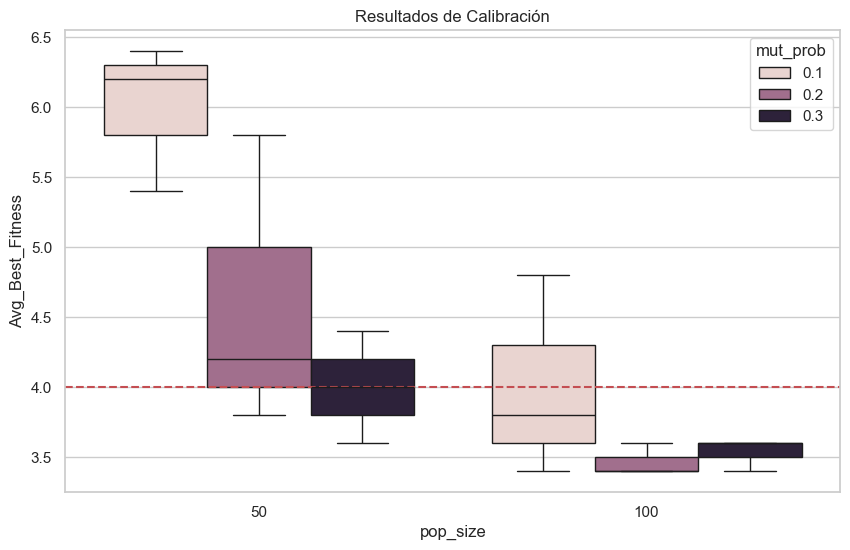

In [5]:
# Gráfica de impacto
plt.figure(figsize=(10, 6))
sns.boxplot(x='pop_size', y='Avg_Best_Fitness', hue='mut_prob', data=df_results)
plt.axhline(y=amd_cost, color='r', linestyle='--', label='AMD Baseline')
plt.title("Resultados de Calibración")
plt.show()